# EXPLORATORY DATA ANALYSIS

In this notebook we are going to analyse all the datasets that we are working with, in order to see not only the behaviour of the variables but also how they interact with our target variable, so that we can later perform a good feature engineering.

In [2]:
import os
import pandas as pd
import numpy as np

# Cambiamos read_csv por read_parquet y actualizamos el nombre del fichero
df = pd.read_parquet('../data_clean/complete_dataset.parquet')
print(f"Data loaded successfully: {df.shape}")

Data loaded successfully: (15488, 26)


In [3]:
df.head()

risk_3   risk_12  logfat_risk_3  logfat_risk_12  INFORM  \
iso3 month                                                                   
AFG  2019-01-01  0.997366  1.000000       8.554694        9.716417     7.7   
     2019-02-01  0.993118  0.997806       8.489241        9.786673     7.7   
     2019-03-01  0.994183  0.997635       8.551225        9.668575     7.7   
     2019-04-01  0.992014  0.997427       8.497727        9.726764     7.7   
     2019-05-01  0.993915  0.998244       8.677351        9.830026     7.8   

                  VU   CC   HA  fatalities  event_count  ...  \
iso3 month                                               ...   
AFG  2019-01-01  7.1  7.5  8.7      3255.0        938.0  ...   
     2019-02-01  7.1  7.5  8.7      2501.0        773.0  ...   
     2019-03-01  7.1  7.5  8.7      3159.0        916.0  ...   
     2019-04-01  7.1  7.5  8.7      2803.0        963.0  ...   
     2019-05-01  7.2  7.5  8.8      3404.0        926.0  ...   

                Violence against civilians     hdx_value  \
iso3 month                                                 
AFG  2019-01-01                       12.0      0.000000   
     2019-02-01                       14.0      0.000000   
     2019-03-01                       29.0  35111.111111   
     2019-04-01                       19.0      0.000000   
     2019-05-01                       25.0      0.000000   

                 hdx_alert_High concern  hdx_alert_Medium concern  \
iso3 month                                                          
AFG  2019-01-01                     0.0                       0.0   
     2019-02-01                     0.0                       0.0   
     2019-03-01                     0.0                       1.0   
     2019-04-01                     0.0                       0.0   
     2019-05-01                     0.0                       0.0   

                 monthly_displacement  inform_severity_index  \
iso3 month                                                     
AFG  2019-01-01          10789.172972               4.133333   
     2019-02-01           9745.059458               4.400000   
     2019-03-01          66039.172976               3.250000   
     2019-04-01          15691.135135               3.350000   
     2019-05-01          10789.172972               4.500000   

                 rolling_3m_displacements  allocation-eligible  target_2m  \
iso3 month                                                                  
AFG  2019-01-01              10789.172972                    0        1.0   
     2019-02-01              20534.232430                    0        1.0   
     2019-03-01              86573.405407                    1        NaN   
     2019-04-01              91475.367569                    1        NaN   
     2019-05-01              92519.481083                    1        1.0   

                 start_conflict  
iso3 month                       
AFG  2019-01-01               0  
     2019-02-01               0  
     2019-03-01               1  
     2019-04-01               0  
     2019-05-01               0  

[5 rows x 26 columns]

In [14]:
df.reset_index(inplace=True)
df.columns.tolist()

['iso3',
 'month',
 'risk_3',
 'risk_12',
 'logfat_risk_3',
 'logfat_risk_12',
 'INFORM',
 'VU',
 'CC',
 'HA',
 'fatalities',
 'event_count',
 'notes_acled',
 'Battles',
 'Explosions/Remote violence',
 'Protests',
 'Riots',
 'Strategic developments',
 'Violence against civilians',
 'hdx_value',
 'hdx_alert_High concern',
 'hdx_alert_Medium concern',
 'monthly_displacement',
 'inform_severity_index',
 'rolling_3m_displacements',
 'allocation-eligible',
 'target_2m',
 'start_conflict']

### ACLED — Armed Conflict Location & Event Data
ACLED records political violence and conflict events at the country-day level, capturing fatalities, event counts, and the nature of conflict activity through the conflict type and the notes section. We expect countries with higher fatality counts and more frequent conflict events to be more likely to meet the CERF allocation-eligibility criteria, as intense conflict is a primary driver of internal displacement. The type of conflict also matters: civilian-targeted violence and heavy warfare are expected to be stronger predictors of displacement than social unrest or political violence.

#### Part 1: Univariate Analysis
This section describes the distribution and coverage of ACLED variables independently of the target variable. The goal is to understand the data quality, detect outliers, and identify patterns in conflict activity across countries and time.

In [15]:
# ACLED variables
acled_cols = ['fatalities',	'event_count', 'notes_acled', 'Battles',
 'Explosions/Remote violence',
 'Protests',
 'Riots',
 'Strategic developments',
 'Violence against civilians']

df[acled_cols].describe().round(2)

,fatalities,event_count,Battles,Explosions/Remote violence,Protests,Riots,Strategic developments,Violence against civilians
count,15488.00,15488.00,15488.00,15488.00,15488.00,15488.00,15488.00,15488.00
mean,88.89,150.67,22.35,27.29,64.57,8.66,11.82,15.98
std,486.19,418.96,112.71,216.81,185.98,34.66,37.91,52.41
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,3.00,0.00,0.00,1.00,0.00,0.00,0.00
50%,0.00,22.00,0.00,0.00,9.00,1.00,1.00,0.00
75%,11.00,110.00,2.00,0.00,46.00,4.00,5.00,6.00
max,27661.00,7059.00,2949.00,4446.00,6584.00,874.00,526.00,619.00


In [16]:
# Missing values
print("Missing values:")
print(df[acled_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[acled_cols].isnull().sum() / len(df) * 100).round(2))

Missing values:
fatalities                    0
event_count                   0
notes_acled                   0
Battles                       0
Explosions/Remote violence    0
Protests                      0
Riots                         0
Strategic developments        0
Violence against civilians    0
dtype: int64

Missing percentage:
fatalities                    0.0
event_count                   0.0
notes_acled                   0.0
Battles                       0.0
Explosions/Remote violence    0.0
Protests                      0.0
Riots                         0.0
Strategic developments        0.0
Violence against civilians    0.0
dtype: float64


The study of the notes explaining the events will be based more on the literature review, not in this notebook, so until now we are only exploring `fatalities`, `event_count` and `Battles`, `Explosions/Remote violence`, `Protests`, `Riots`, `Strategic developments` and `Violence against civilians`.

In [17]:
acled_cols = ['fatalities',	'event_count', 'notes_acled', 'Battles',
 'Explosions/Remote violence',
 'Protests',
 'Riots',
 'Strategic developments',
 'Violence against civilians']

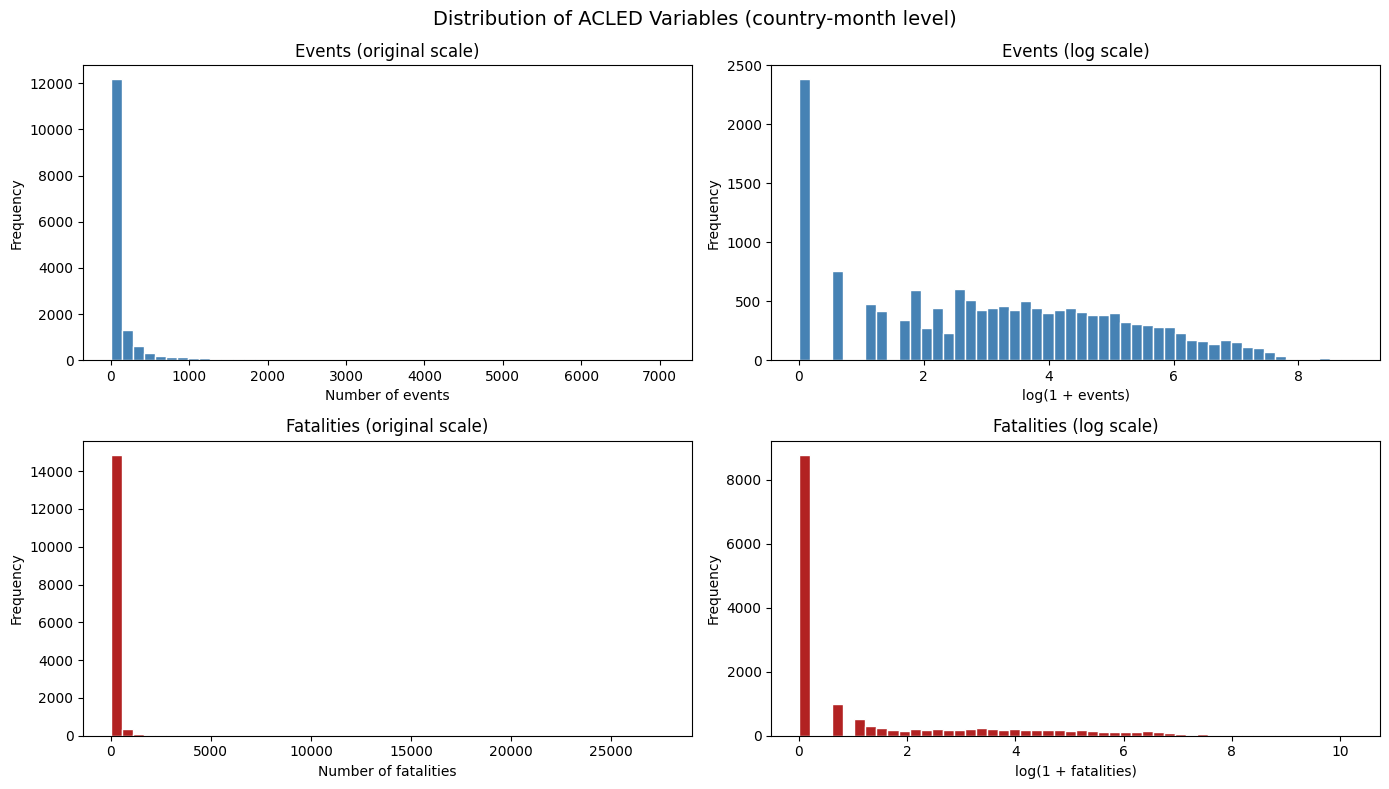

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of ACLED Variables (country-month level)', fontsize=14)

# Events - original
axes[0, 0].hist(df['event_count'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Events (original scale)')
axes[0, 0].set_xlabel('Number of events')
axes[0, 0].set_ylabel('Frequency')

# Events - log
axes[0, 1].hist(np.log1p(df['event_count']), bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Events (log scale)')
axes[0, 1].set_xlabel('log(1 + events)')
axes[0, 1].set_ylabel('Frequency')

# Fatalities - original
axes[1, 0].hist(df['fatalities'], bins=50, color='firebrick', edgecolor='white')
axes[1, 0].set_title('Fatalities (original scale)')
axes[1, 0].set_xlabel('Number of fatalities')
axes[1, 0].set_ylabel('Frequency')

# Fatalities - log
axes[1, 1].hist(np.log1p(df['fatalities']), bins=50, color='firebrick', edgecolor='white')
axes[1, 1].set_title('Fatalities (log scale)')
axes[1, 1].set_xlabel('log(1 + fatalities)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Both variables show a strong right-skewed distribution at the country-month level. For `event_count`, most country-months record fewer than 500 events, with a few extreme cases reaching over 8,000. For `fatalities`, the skew is even more pronounced, over half of all country-months report zero fatalities, meaning that conflict-related deaths are concentrated in a small number of countries and time periods. Even after applying the log(1+x) transformation, the spike at zero remains dominant for fatalities, confirming that conflict is a rare and concentrated phenomenon in this dataset. This is consistent with the low share of allocation-eligible observations (3.9%) in the target variable.

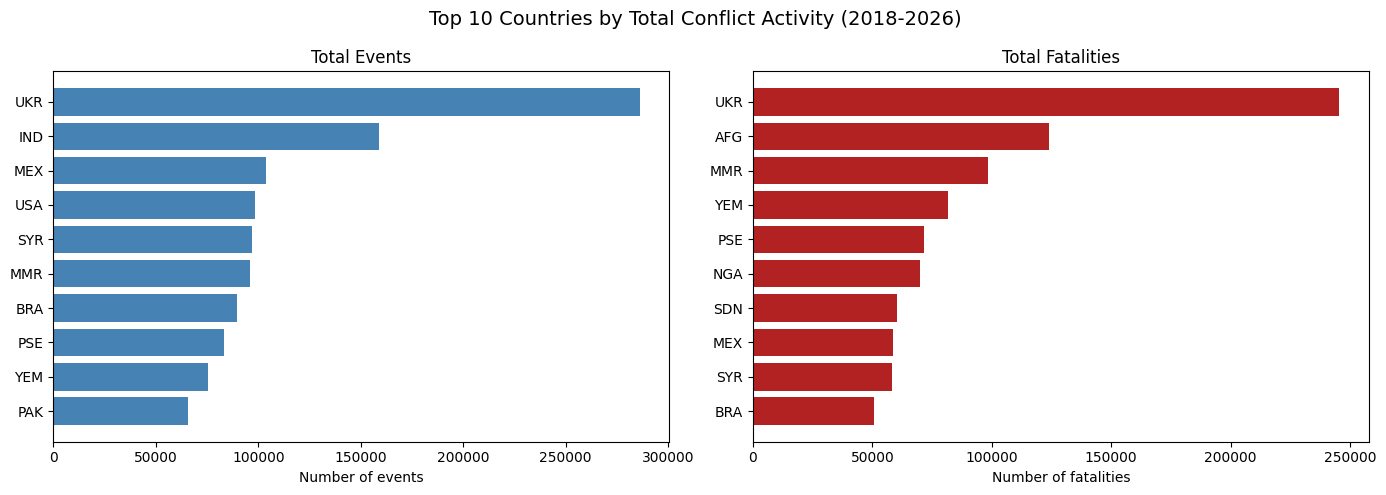

In [19]:
# Top 10 countries by total events and fatalities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top 10 Countries by Total Conflict Activity (2018-2026)', fontsize=14)

# Top 10 by events
top_events = df.groupby('iso3')['event_count'].sum().nlargest(10)
axes[0].barh(top_events.index[::-1], top_events.values[::-1], color='steelblue')
axes[0].set_title('Total Events')
axes[0].set_xlabel('Number of events')

# Top 10 by fatalities
top_fatalities = df.groupby('iso3')['fatalities'].sum().nlargest(10)
axes[1].barh(top_fatalities.index[::-1], top_fatalities.values[::-1], color='firebrick')
axes[1].set_title('Total Fatalities')
axes[1].set_xlabel('Number of fatalities')

plt.tight_layout()
plt.show()

The charts display the top 10 countries by total accumulated events and fatalities over the study period. Ukraine ranks first in both lists, which is expected given the scale of conflict following the Russian invasion in 2022. While several countries appear in both rankings, the order differs, suggesting that conflict frequency and lethality do not always go hand in hand. Some countries record many events with relatively few deaths, while others concentrate high fatality counts in fewer but more deadly incidents. This confirms that both variables capture different dimensions of conflict.

In [20]:
# Extract year from month
df['year'] = pd.to_datetime(df['month']).dt.year

# Average monthly events and fatalities by year
yearly_avg = df.groupby('year')[['event_count', 'fatalities']].mean().round(2)
yearly_avg.columns = ['Avg Monthly Events', 'Avg Monthly Fatalities']
yearly_avg

,Avg Monthly Events,Avg Monthly Fatalities
year,,
2019,109.25,73.38
2020,126.99,66.14
2021,137.95,75.95
2022,151.51,80.34
2023,166.12,94.69
2024,185.64,117.96
2025,192.73,113.34
2026,104.10,90.05


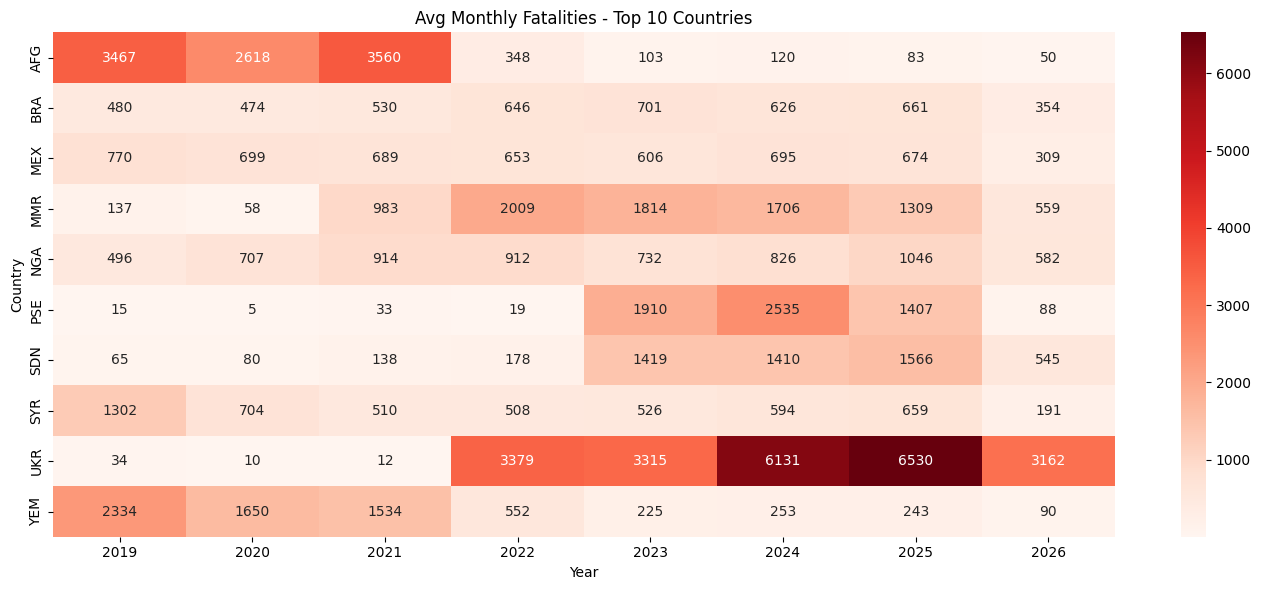

In [21]:
import seaborn as sns

# Top 10 countries by total fatalities
top10_fatalities = df.groupby('iso3')['fatalities'].sum().nlargest(10).index

yearly_country = df[df['iso3'].isin(top10_fatalities)].groupby(['year', 'iso3'])['fatalities'].mean().round(2)

pivot_fatalities = yearly_country.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_fatalities, cmap='Reds', fmt='.0f', annot=True, ax=ax)
ax.set_title('Avg Monthly Fatalities - Top 10 Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

The heatmap displays the average monthly fatalities for the 10 countries with the highest cumulative death over the study period (2018-2026). These countries are concentrated in conflict-prone regions: the Middle East (Syria, Yemen, Palestine), Sub-Saharan Africa (Nigeria, Sudan), Southeast Asia (Myanmar), Eastern Europe (Ukraine), and South Asia (Afghanistan). Several patterns stand out. Afghanistan recorded the highest monthly averages between 2018 and 2021 (above 3,000 deaths per month), dropping sharply after the Taliban takeover in August 2021. Ukraine shows the opposite trend , nearly no fatalities before 2022, then surging to over 6,000 monthly deaths by 2024 following the Russian invasion. Palestine (PSE) follows a similar pattern, remaining low until 2023 when the Gaza conflict began. Mexico is a notable case, it consistently appears in the top 10 despite not being associated with conventional armed conflict. Its presence reflects ongoing cartel-related violence, which ACLED classifies as political violence, resulting in hundreds of fatalities every month throughout the entire period.

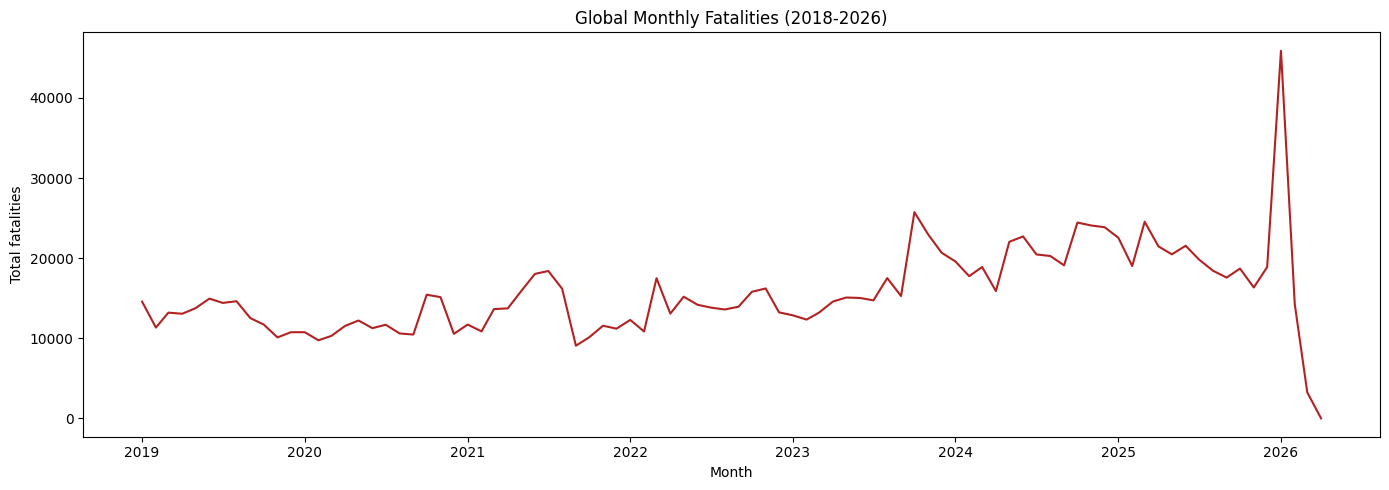

In [22]:
# Global monthly fatalities over time
global_monthly = df.groupby('month')['fatalities'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pd.to_datetime(global_monthly['month']), global_monthly['fatalities'], 
        color='firebrick', linewidth=1.5)
ax.set_title('Global Monthly Fatalities (2018-2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Total fatalities')
plt.tight_layout()
plt.show()

In [23]:
# Identify which country drives the 2026 spike
spike_2026 = df[pd.to_datetime(df['month']).dt.year == 2026].groupby('iso3')['fatalities'].sum().nlargest(10)
print(spike_2026)

iso3
IRN    28136.0
UKR    12649.0
NGA     2330.0
MMR     2237.0
SDN     2179.0
SOM     1672.0
BRA     1415.0
ETH     1274.0
MEX     1235.0
PAK     1052.0
Name: fatalities, dtype: float64


The global monthly fatalities series shows a relatively stable baseline between 2018 and 2022, ranging between 10,000 and 20,000 deaths per month. From 2023 onward, a clear upward trend emerges, driven by the simultaneous escalation of multiple active conflicts ,particularly Ukraine, Sudan, and Gaza  pushing monthly totals consistently above 20,000. The sharp spike in early 2026 is largely explained by Iran (IRN), which accumulates nearly 29,000 fatalities in the first months of the year, far above its historical levels. This anomaly should be interpreted with caution, as the dataset only covers up to April 2026 and recent observations may reflect incomplete or retroactively corrected ACLED records rather than a sudden escalation of conflict. In general, the series confirms that global conflict intensity has increased over the study period, with the post-2022 period being notably more lethal than the years prior.

#### Part 2: Bivariate Analysis

This section examines how ACLED variables behave in relation to the target variable `allocation-eligible`. The goal is to assess whether conflict frequency and fatalities are systematically higher in country-months where the CERF allocation criteria are met, which would support their use as predictors in the early warning model.

In [24]:
# Mean fatalities by allocation-eligible
df.groupby('allocation-eligible')['fatalities'].mean().round(2)

allocation-eligible
0     54.83
1    956.53
Name: fatalities, dtype: float64

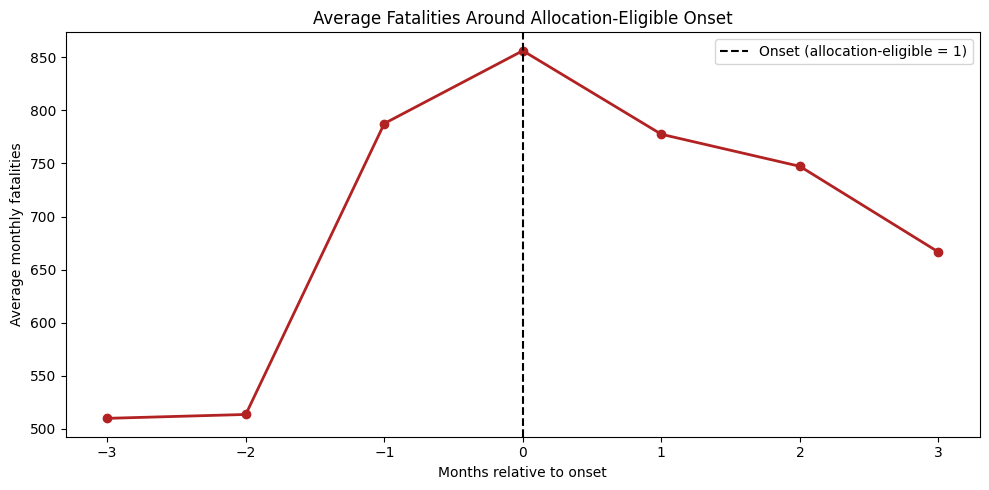

In [25]:
# Window around allocation-eligible onset
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['iso3', 'month'])

# Find months where allocation-eligible turns 1 (onset)
df['prev_eligible'] = df.groupby('iso3')['allocation-eligible'].shift(1)
onset = df[(df['allocation-eligible'] == 1) & (df['prev_eligible'] == 0)][['iso3', 'month']].copy()

# Build window of -3 to +3 months around each onset
windows = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-3, 4):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows.append({'iso3': country, 'months_to_onset': t, 
                          'fatalities': match['fatalities'].values[0]})

window_df = pd.DataFrame(windows)

# Average fatalities by months_to_onset
avg_window = window_df.groupby('months_to_onset')['fatalities'].mean().round(2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_window.index, avg_window.values, color='firebrick', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Fatalities Around Allocation-Eligible Onset')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average monthly fatalities')
ax.legend()
plt.tight_layout()
plt.show()

To assess whether conflict fatalities anticipate humanitarian crises, we constructed a event window around each allocation-eligible onset. An onset is defined as the first month in which a country transitions from non-eligible to eligible status. For each onset observed in the dataset, we extracted fatality values from 3 months before to 3 months after, then averaged across all onsets globally.

The chart reveals a clear upward trend in the months preceding the onset. Average monthly fatalities rise from approximately 580 deaths at t-3 to nearly 1,000 at t=0, the onset month itself. After the onset, fatalities gradually decline but remain elevated, suggesting that conflict intensity persists even after the crisis is officially recognized. This pattern confirms that fatalities carry predictive signal ahead of the onset of allocation-eligible periods, supporting the inclusion of ACLED fatality data as a predictor in the early warning model.

In [26]:
# Check number of onsets and where they occur
print(f"Total onsets detected: {len(onset)}")
print(f"\nOnsets by year:")
print(onset['month'].dt.year.value_counts().sort_index())
print(f"\nOnsets by country:")
print(onset['iso3'].value_counts().head(20))

Total onsets detected: 99

Onsets by year:
month
2019     7
2020     7
2021     9
2022    12
2023    18
2024    19
2025    23
2026     4
Name: count, dtype: int64

Onsets by country:
iso3
ETH    8
SYR    7
PHL    6
SOM    6
AFG    5
CAF    5
NGA    5
SDN    5
HTI    4
LBN    4
PSE    4
SSD    4
BFA    3
MLI    3
MOZ    3
NER    3
CMR    2
IRN    2
KHM    2
MMR    2
Name: count, dtype: int64


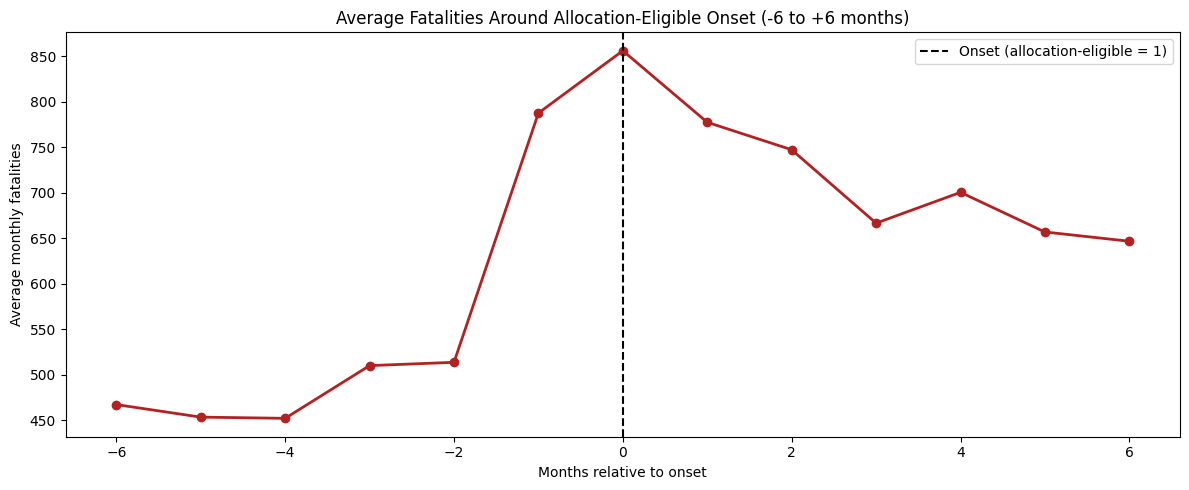

In [27]:
# Build window of -6 to +6 months around each onset
windows = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows.append({'iso3': country, 'months_to_onset': t, 
                          'fatalities': match['fatalities'].values[0]})

window_df = pd.DataFrame(windows)

# Average fatalities by months_to_onset
avg_window = window_df.groupby('months_to_onset')['fatalities'].mean().round(2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_window.index, avg_window.values, color='firebrick', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Fatalities Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average monthly fatalities')
ax.legend()
plt.tight_layout()
plt.show()

Expanding the window to 6 months before and after the onset reveals that fatalities remain relatively stable between t-6 and t-3, moving around 530-580 deaths per month. The sharpest increase occurs between t-2 and t=0, where the average jumps from approximately 620 to nearly 1,000 fatalities, suggesting that the predictive signal in fatalities is concentrated in the 2-3 months immediately preceding the onset rather than further in advance.

This has two important implications for the model. First, short lags (1-2 months) are likely to be more informative than longer ones. Second, fatalities behave as a late warning signal, useful for detection but with limited anticipation capacity. This is consistent with the 2-month prediction horizon of the target variable `target_2m`.



### IDMC — Internal Displacement Monitoring Centre

IDMC tracks conflict-induced internal displacements at the country-day level, aggregated here to country-month. `monthly_displacement` captures the number of new internally displaced persons (IDPs) registered each month due to conflict. This variable is central to the project as it directly feeds into the construction of `allocation-eligible`, a country meets the CERF criteria when it accumulates 50,000 or more new displacements over a 3-month period. For this reason.

In [28]:
# Descriptive statistics - monthly displacement
print(df['monthly_displacement'].describe().round(2))
print(f"\nMissing values: {df['monthly_displacement'].isnull().sum()}")
print(f"Missing percentage: {(df['monthly_displacement'].isnull().sum() / len(df) * 100).round(2)}%")

count      15488.00
mean        5537.30
std        62764.03
min            0.00
25%            0.00
50%            0.00
75%            0.00
max      4000000.00
Name: monthly_displacement, dtype: float64

Missing values: 0
Missing percentage: 0.0%


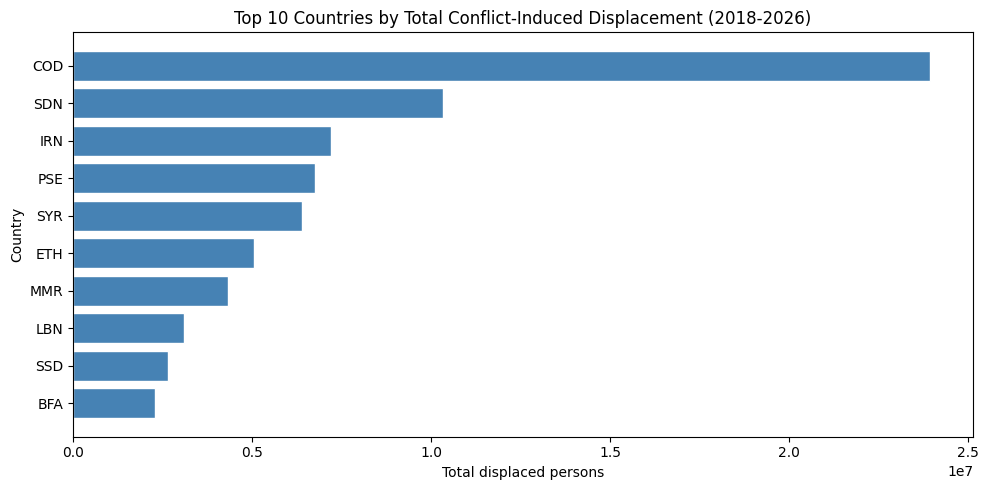

In [29]:
import matplotlib.pyplot as plt

# Top 10 countries by total displacement
top10_disp = df.groupby('iso3')['monthly_displacement'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_disp.index[::-1], top10_disp.values[::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 10 Countries by Total Conflict-Induced Displacement (2018-2026)')
ax.set_xlabel('Total displaced persons')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

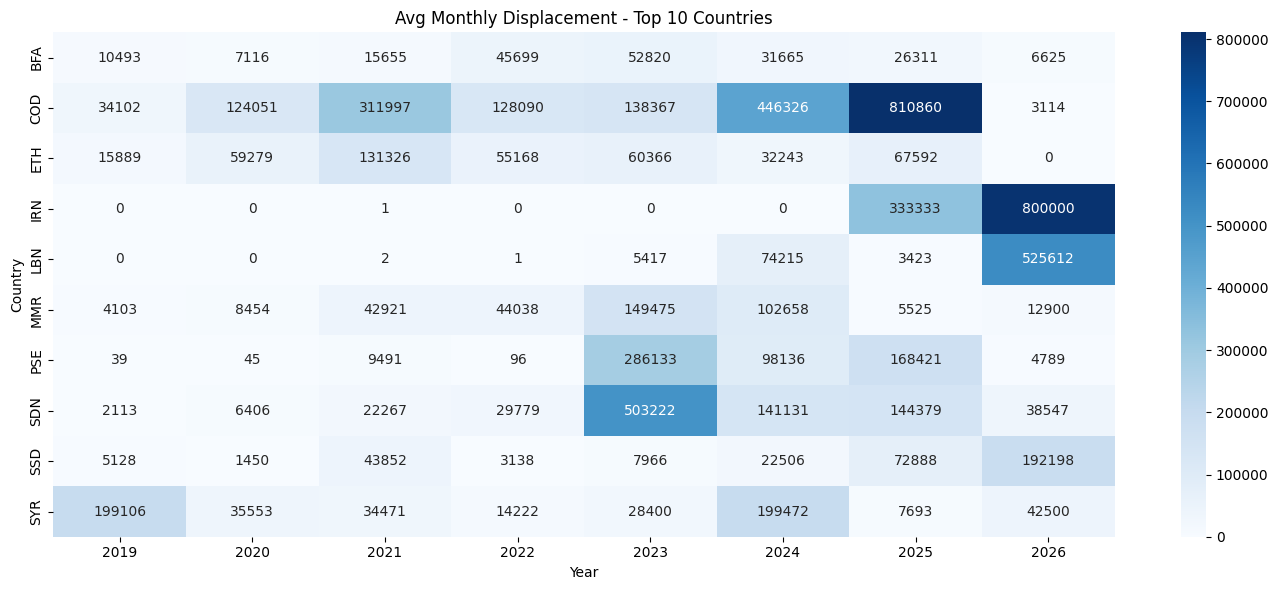

In [30]:
import seaborn as sns

df['year'] = pd.to_datetime(df['month']).dt.year

# Top 10 countries by total displacement
top10_disp = df.groupby('iso3')['monthly_displacement'].sum().nlargest(10).index

yearly_disp = df[df['iso3'].isin(top10_disp)].groupby(['year', 'iso3'])['monthly_displacement'].mean().round(0)

pivot_disp = yearly_disp.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_disp, cmap='Blues', fmt='.0f', annot=True, ax=ax)
ax.set_title('Avg Monthly Displacement - Top 10 Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

The heatmap shows the average monthly conflict-induced displacement for the 10 countries with the highest cumulative totals over the study period. COD(Democratic Republic of Congo) stands out as the most affected country throughout the entire period, with displacement levels rising sharply in 2024-2025 to over 800,000 persons per month on average. Several countries show sudden escalations tied to specific conflict events. Sudan (SDN) records a sharp spike in 2023 coinciding with the outbreak of civil war between the SAF and RSF forces. Palestine (PSE) shows near-zero displacement until 2023, when the Gaza conflict begins. Iran (IRN) and Lebanon (LBN) appear relatively stable until 2025-2026, when displacement surges to over 1 million and 700,000 monthly respectively, likely linked to regional escalation in the Middle East. Syria (SYR) shows a different pattern , high displacement in the early years of the study period that gradually declines, reflecting the de-escalation of the Syrian civil war after its peak years.

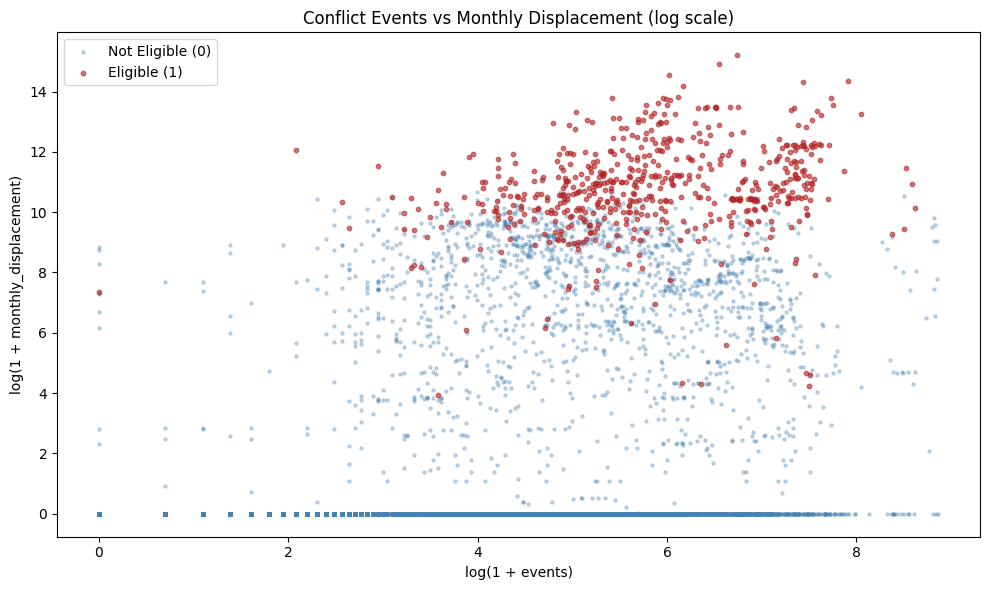

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

# Non-eligible
mask0 = df['allocation-eligible'] == 0
ax.scatter(np.log1p(df[mask0]['event_count']), np.log1p(df[mask0]['monthly_displacement']),
           alpha=0.3, color='steelblue', s=5, label='Not Eligible (0)')

# Eligible
mask1 = df['allocation-eligible'] == 1
ax.scatter(np.log1p(df[mask1]['event_count']), np.log1p(df[mask1]['monthly_displacement']),
           alpha=0.6, color='firebrick', s=10, label='Eligible (1)')

ax.set_title('Conflict Events vs Monthly Displacement (log scale)')
ax.set_xlabel('log(1 + events)')
ax.set_ylabel('log(1 + monthly_displacement)')
ax.legend()
plt.tight_layout()
plt.show()

The scatter plot examines the relationship between conflict activity (ACLED events) and conflict-induced displacement (IDMC) at the country-month level, with both variables on a log scale. Each point represents a country-month observation, colored by allocation-eligible status. Countries that are allocation-eligible (red) cluster in the upper-right region of the chart, indicating that crisis months are characterized by simultaneously high conflict activity and high displacement. In contrast, non-eligible months (blue) are widely dispersed, with a large concentration along y=0, reflecting country-months where conflict events occur but produce no recorded displacement. This pattern suggests that while conflict and displacement are positively associated, not all conflict translates into displacement, the co-occurrence of both at high levels is what characterizes allocation-eligible situations. This reinforces the complementarity of ACLED and IDMC as predictors in the early warning model.

### HDX Signals 


In [34]:
# HDX base variables
hdx_cols = ['hdx_alert_Medium concern', 'hdx_alert_High concern', 'hdx_value']

print(df[hdx_cols].describe(include='all').round(2))

print(f"\nMissing values:")
print(df[hdx_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[hdx_cols].isnull().sum() / len(df) * 100).round(2))

       hdx_alert_Medium concern  hdx_alert_High concern   hdx_value
count                  15488.00                15488.00    15488.00
mean                       0.04                    0.02     3274.56
std                        0.21                    0.17    64662.87
min                        0.00                    0.00        0.00
25%                        0.00                    0.00        0.00
50%                        0.00                    0.00        0.00
75%                        0.00                    0.00        0.00
max                        3.00                    3.00  4008840.81

Missing values:
hdx_alert_Medium concern    0
hdx_alert_High concern      0
hdx_value                   0
dtype: int64

Missing percentage:
hdx_alert_Medium concern    0.0
hdx_alert_High concern      0.0
hdx_value                   0.0
dtype: float64


In [36]:
# Distribution of alert level
print(df['hdx_alert_Medium concern'].value_counts())
print(df['hdx_alert_High concern'].value_counts())

hdx_alert_Medium concern
0.0    14891
1.0      560
2.0       35
3.0        2
Name: count, dtype: int64
hdx_alert_High concern
0.0    15146
1.0      314
2.0       27
3.0        1
Name: count, dtype: int64


In [37]:
# Descriptive statistics for hdx_value
print(df['hdx_value'].describe().round(2))
print(f"\nMissing values: {df['hdx_value'].isnull().sum()}")
print(f"Missing percentage: {(df['hdx_value'].isnull().sum() / len(df) * 100).round(2)}%")

count      15488.00
mean        3274.56
std        64662.87
min            0.00
25%            0.00
50%            0.00
75%            0.00
max      4008840.81
Name: hdx_value, dtype: float64

Missing values: 0
Missing percentage: 0.0%


In [38]:
# Find the observation with the maximum hdx_value
print(df[df['hdx_value'] == df['hdx_value'].max()][['iso3', 'month', 'hdx_alert_Medium concern', 'hdx_alert_High concern', 'hdx_value']])

     iso3      month  hdx_alert_Medium concern  hdx_alert_High concern  \
2670  CHN 2021-07-01                       1.0                     1.0   

         hdx_value  
2670  4.008841e+06  


This is possible an oultlier.

In [40]:
df['hdx_alert_simple'] = np.where(
    df['hdx_alert_High concern'] > 0, 'High concern',
    np.where(
        df['hdx_alert_Medium concern'] > 0, 'Medium concern',
        'No alert'
    )
)

mask = df['hdx_alert_simple'] != 'No alert'

crosstab_result = pd.crosstab(
    df[mask]['allocation-eligible'], 
    df[mask]['hdx_alert_simple'], 
    normalize='index'
).round(3) * 100

crosstab_result

hdx_alert_simple,High concern,Medium concern
allocation-eligible,,
0,36.1,63.9
1,51.1,48.9


The crosstab reveals two important findings about HDX Signals coverage and predictive value. First, the variable has very sparse coverage , 95.5% of non-eligible country-months and 70.1% of eligible country-months have no alert recorded, reflecting that HDX only flags a small subset of humanitarian situations.

Second, despite this limitation, there is a clear difference between groups. Allocation-eligible country-months are almost 7 times more likely to have an alert than non-eligible ones (29.9% vs 4.4%), and show a higher proportion of "High concern" alerts (15.9% vs 1.5%). This suggests that when HDX does register an alert, it tends to coincide with genuine crisis situations. Given its sparse coverage, HDX Signals should be treated as a complementary signal rather than a primary predictor in the early warning model.

### EconAI — Conflict Risk Predictions

EconAI generates monthly country-level predictions of armed conflict. It produces four variables used in this project:

- `risk_3`: predicted probability of armed conflict onset in the next 3 months
- `risk_12`: predicted probability of armed conflict onset in the next 12 months
- `logfat_risk_3`: predicted fatalities in log scale at a 3-month horizon
- `logfat_risk_12`: predicted fatalities in log scale at a 12-month horizon

These variables are particularly valuable because they already embed conflict forecasting signal from an external model, making them strong candidate predictors for the early warning system. Unlike ACLED and IDMC which capture observed conflict, EconAI captures anticipated conflict risk,a more direct input for a predictive model.

In [41]:
# Descriptive statistics - EconAI variables
econai_cols = ['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12']

df[econai_cols].describe().round(3)

,risk_3,risk_12,logfat_risk_3,logfat_risk_12
count,15312.000,15312.000,15312.000,15312.000
mean,0.174,0.239,1.229,1.811
std,0.319,0.348,2.116,2.633
min,0.004,0.003,0.006,0.028
25%,0.006,0.011,0.008,0.049
50%,0.012,0.043,0.086,0.329
75%,0.112,0.318,1.411,2.850
max,1.000,1.000,9.763,10.689


In [42]:
# Missing values
print("Missing values:")
print(df[econai_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[econai_cols].isnull().sum() / len(df) * 100).round(2))

Missing values:
risk_3            176
risk_12           176
logfat_risk_3     176
logfat_risk_12    176
dtype: int64

Missing percentage:
risk_3            1.14
risk_12           1.14
logfat_risk_3     1.14
logfat_risk_12    1.14
dtype: float64


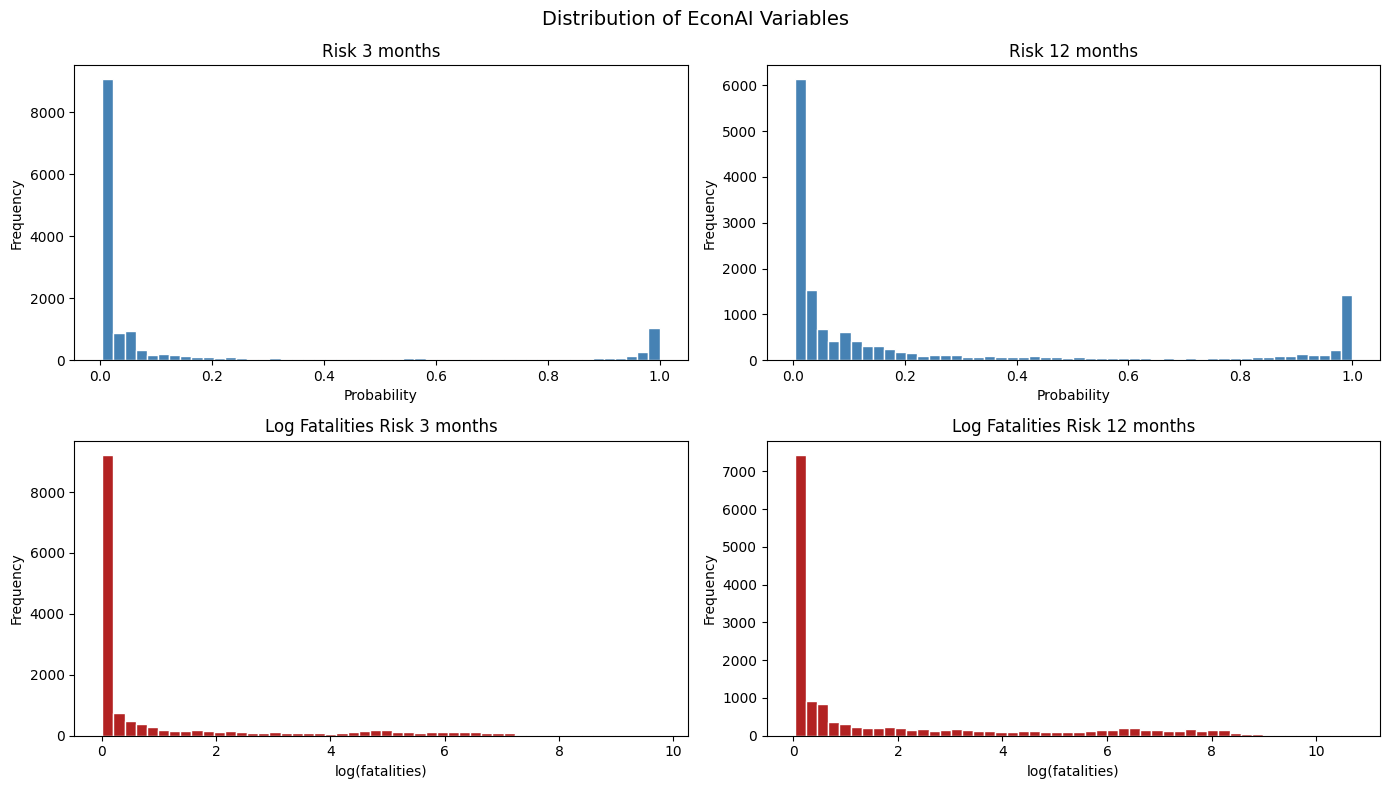

In [43]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of EconAI Variables', fontsize=14)

# risk_3
axes[0, 0].hist(df['risk_3'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Risk 3 months')
axes[0, 0].set_xlabel('Probability')
axes[0, 0].set_ylabel('Frequency')

# risk_12
axes[0, 1].hist(df['risk_12'], bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('Risk 12 months')
axes[0, 1].set_xlabel('Probability')
axes[0, 1].set_ylabel('Frequency')

# logfat_risk_3
axes[1, 0].hist(df['logfat_risk_3'], bins=50, color='firebrick', edgecolor='white')
axes[1, 0].set_title('Log Fatalities Risk 3 months')
axes[1, 0].set_xlabel('log(fatalities)')
axes[1, 0].set_ylabel('Frequency')

# logfat_risk_12
axes[1, 1].hist(df['logfat_risk_12'], bins=50, color='firebrick', edgecolor='white')
axes[1, 1].set_title('Log Fatalities Risk 12 months')
axes[1, 1].set_xlabel('log(fatalities)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

All four EconAI variables show a strongly right-skewed distribution. For `risk_3` and `risk_12`, the majority of country-months receive very low conflict probabilities, concentrated near zero. However, both distributions show a notable secondary spike near 1.0, reflecting countries where EconAI assigns near-certainty of armed conflict typically chronic conflict contexts such as Afghanistan, Syria, or Yemen. `risk_12` shows a less extreme initial spike compared to `risk_3`, consistent with the descriptive statistics, at a 12-month horizon, the model assigns higher average probabilities since the accumulation window is longer. This is expected behavior for a conflict forecasting model.

The log fatality predictions follow a similar pattern , most country-months receive low predicted fatalities, with a long tail of high-risk observations. Neither variable contains missing values, confirming full coverage across the dataset.

In [44]:
# Top 10 countries by average risk_3, risk_12, logfat_risk_3, logfat_risk_12
econai_cols = ['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12']

for col in econai_cols:
    print(f"\n=== Top 10 Countries by avg {col} ===")
    print(df.groupby('iso3')[col].mean().nlargest(10).round(3))


=== Top 10 Countries by avg risk_3 ===
iso3
COD    0.997
MLI    0.993
SYR    0.990
CMR    0.987
BFA    0.986
YEM    0.980
CAF    0.975
MEX    0.973
SOM    0.964
NGA    0.951
Name: risk_3, dtype: float64

=== Top 10 Countries by avg risk_12 ===
iso3
COD    0.998
MLI    0.997
SOM    0.997
BFA    0.995
SYR    0.994
CMR    0.993
YEM    0.989
CAF    0.987
MEX    0.987
NER    0.979
Name: risk_12, dtype: float64

=== Top 10 Countries by avg logfat_risk_3 ===
iso3
MEX    7.250
UKR    7.196
COD    6.762
SYR    6.623
NGA    6.600
AFG    6.458
SOM    6.417
YEM    6.381
ETH    6.287
BFA    6.079
Name: logfat_risk_3, dtype: float64

=== Top 10 Countries by avg logfat_risk_12 ===
iso3
MEX    8.536
UKR    8.287
COD    8.122
SYR    8.041
AFG    8.026
NGA    7.952
YEM    7.836
SOM    7.806
ETH    7.769
BFA    7.514
Name: logfat_risk_12, dtype: float64


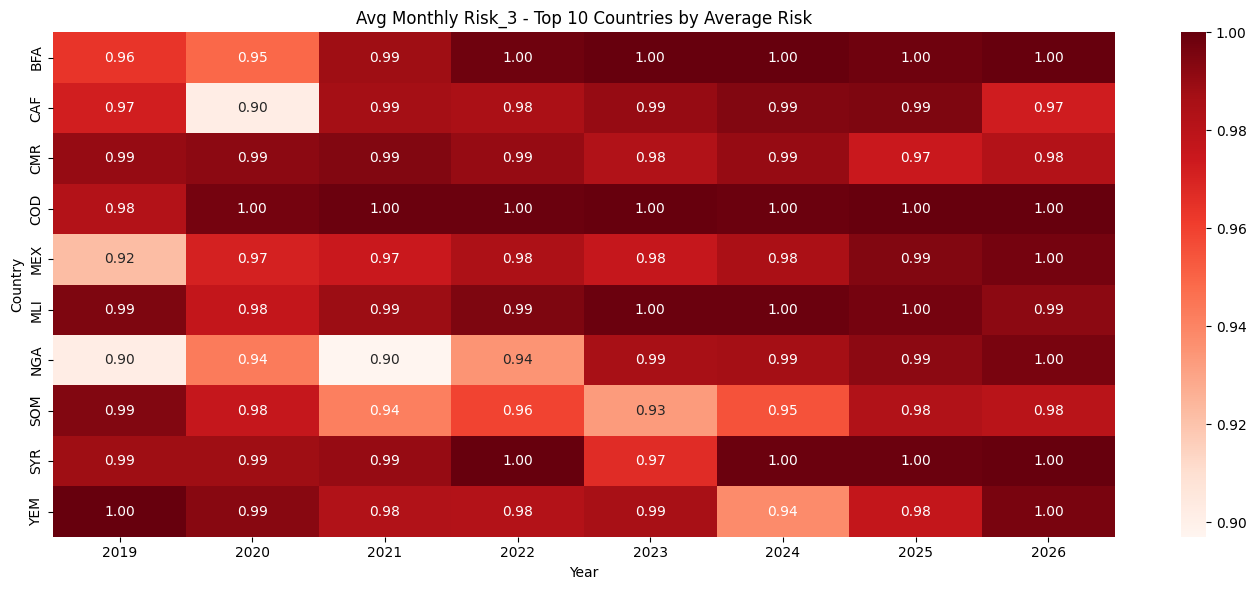

In [45]:
import seaborn as sns

df['year'] = pd.to_datetime(df['month']).dt.year

# Top 10 countries by average risk_3
top10_risk = df.groupby('iso3')['risk_3'].mean().nlargest(10).index

yearly_risk = df[df['iso3'].isin(top10_risk)].groupby(['year', 'iso3'])['risk_3'].mean().round(3)

pivot_risk = yearly_risk.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_risk, cmap='Reds', fmt='.2f', annot=True, ax=ax)
ax.set_title('Avg Monthly Risk_3 - Top 10 Countries by Average Risk')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

The heatmap shows average monthly `risk_3` for the 10 highest-risk countries. Most cells are near 1.0 throughout the entire period, reflecting that EconAI assigns near-certain conflict probability to chronic conflict contexts like Somalia, Yemen, and Congo. The most notable pattern is Burkina Faso (BFA), which starts at 0.45 in 2018 and reaches 1.0 by 2022, capturing the rapid escalation of jihadist violence in the Sahel. Mexico (MEX) shows a similar upward trend, consistent with the intensification of cartel-related violence over the period.

#### Part 2: Bivariate Analysis

This section examines how EconAI risk predictions behave in relation to `allocation-eligible`. The expectation is that countries meeting the CERF criteria should show systematically higher conflict risk scores, validating the predictive signal embedded in EconAI variables.

In [46]:
# Mean risk by allocation-eligible
df.groupby('allocation-eligible')[['risk_3', 'risk_12', 'logfat_risk_3', 'logfat_risk_12']].mean().round(3)

,risk_3,risk_12,logfat_risk_3,logfat_risk_12
allocation-eligible,,,,
0,0.144,0.210,1.026,1.575
1,0.936,0.974,6.364,7.759


The comparison of EconAI variables across allocation-eligible groups reveals a difference. Countries that are allocation-eligible show an average `risk_3` of 0.917 compared to 0.141 for non-eligible countries, a difference of more than six times. The same pattern holds for `risk_12` (0.961 vs 0.207).

For the log fatality predictions, the gap is even more pronounced. Eligible countries show a `logfat_risk_3` of 6.291, which translates to approximately 540 predicted fatalities per month in real terms (e^6.291). Non-eligible countries average 1.006 in log scale, equivalent to roughly 2.7 fatalities, a negligible level.

These results confirm that EconAI variables carry strong discriminative power between crisis and non-crisis country-months, making them valuable predictors in the early warning model. The particularly high separation in `risk_3` is especially relevant given that the target variable operates on a 2-month prediction horizon.

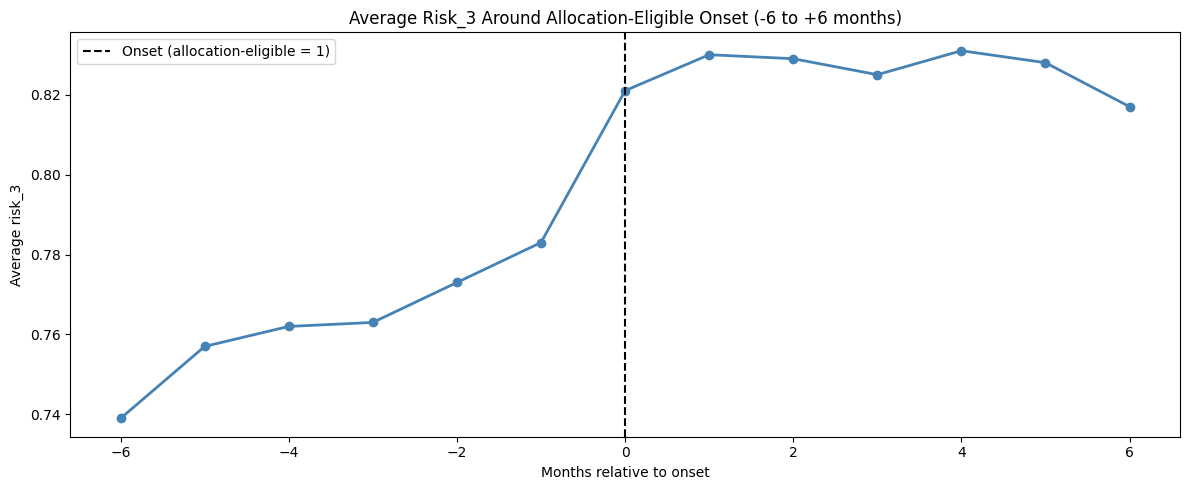

In [47]:
# Window around onset for risk_3
df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['iso3', 'month'])

df['prev_eligible'] = df.groupby('iso3')['allocation-eligible'].shift(1)
onset = df[(df['allocation-eligible'] == 1) & (df['prev_eligible'] == 0)][['iso3', 'month']].copy()

windows_risk3 = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_risk3.append({'months_to_onset': t, 
                                  'risk_3': match['risk_3'].values[0]})

window_df_risk3 = pd.DataFrame(windows_risk3)
avg_risk3 = window_df_risk3.groupby('months_to_onset')['risk_3'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_risk3.index, avg_risk3.values, color='steelblue', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Risk_3 Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average risk_3')
ax.legend()
plt.tight_layout()
plt.show()

`risk_3` shows a steady upward trend starting from t-6, rising from 0.74 to 0.82 at the onset. Unlike fatalities, where the signal was concentrated in the last 2 months before onset, EconAI anticipates the crisis gradually and consistently from 6 months in advance. After the onset, risk remains elevated around 0.83, reflecting that conflict contexts persist once they begin. This earlier and smoother anticipation pattern strengthens the case for including `risk_3` as a predictor, as it provides a longer warning window than observed conflict variables like ACLED fatalities.

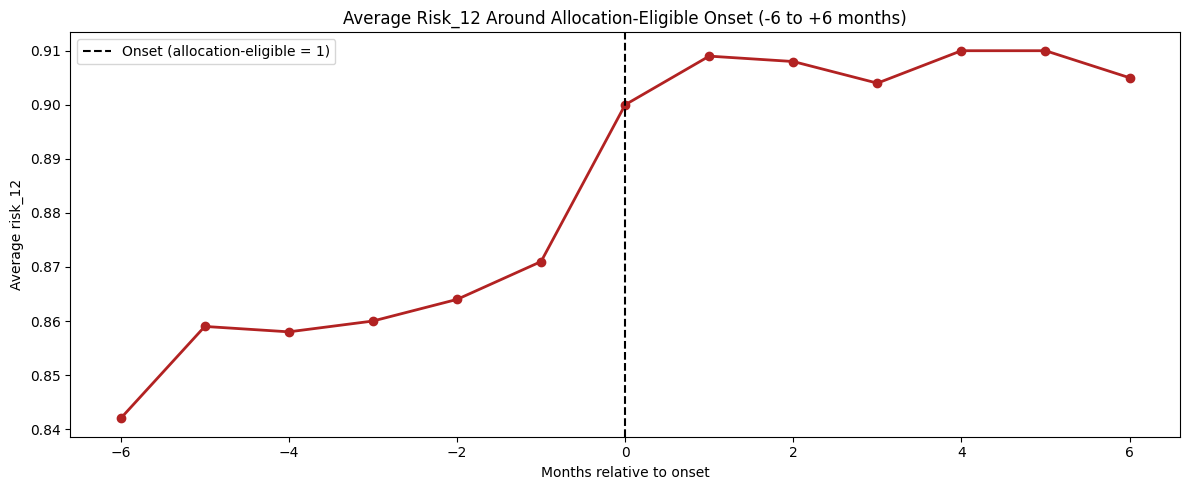

In [48]:
# Window around onset for risk_12
windows_risk12 = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_risk12.append({'months_to_onset': t,
                                   'risk_12': match['risk_12'].values[0]})

window_df_risk12 = pd.DataFrame(windows_risk12)
avg_risk12 = window_df_risk12.groupby('months_to_onset')['risk_12'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_risk12.index, avg_risk12.values, color='firebrick', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average Risk_12 Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average risk_12')
ax.legend()
plt.tight_layout()
plt.show()

`risk_12` follows the same upward pattern as `risk_3`, rising from 0.84 at t-6 to 0.90 at the onset and stabilizing around 0.91 afterwards. The key difference is that baseline values are higher throughout, as the 12-month horizon naturally captures more accumulated conflict risk. Both variables confirm that EconAI anticipates allocation-eligible crises from at least 6 months in advance, making them strong early warning predictors.

### INFORM Risk Index

The INFORM Risk Index is a composite indicator that measures the risk of humanitarian crisis and disaster at the country level based on three dimensions:

- `INFORM`: composite risk score (0-10 scale)
- `HA`: Hazard & Exposure — likelihood of a hazardous event occurring
- `VU`: Vulnerability — susceptibility of people to the effects of hazards
- `CC`: Coping Capacity — ability of governments and communities to manage disasters

Unlike ACLED and IDMC which capture observed conflict, INFORM measures structural and chronic risk factors. A country with a high INFORM score is not necessarily in active conflict, but is more vulnerable to humanitarian crises when shocks occur. This makes it a complementary predictor to more dynamic variables like EconAI or ACLED.

In [49]:
# INFORM variables
inform_cols = ['INFORM', 'VU', 'CC', 'HA']

print(df[inform_cols].describe().round(2))
print(f"\nMissing values:")
print(df[inform_cols].isnull().sum())
print(f"\nMissing percentage:")
print((df[inform_cols].isnull().sum() / len(df) * 100).round(2))

         INFORM        VU        CC        HA
count  15488.00  15488.00  15488.00  15488.00
mean       3.81      3.82      4.44      3.67
std        1.80      1.96      1.94      2.24
min        0.40      0.30      0.90      0.10
25%        2.40      2.20      2.90      1.90
50%        3.70      3.60      4.40      3.10
75%        5.00      5.30      5.93      5.20
max        9.10      9.40      9.50      9.20

Missing values:
INFORM    0
VU        0
CC        0
HA        0
dtype: int64

Missing percentage:
INFORM    0.0
VU        0.0
CC        0.0
HA        0.0
dtype: float64


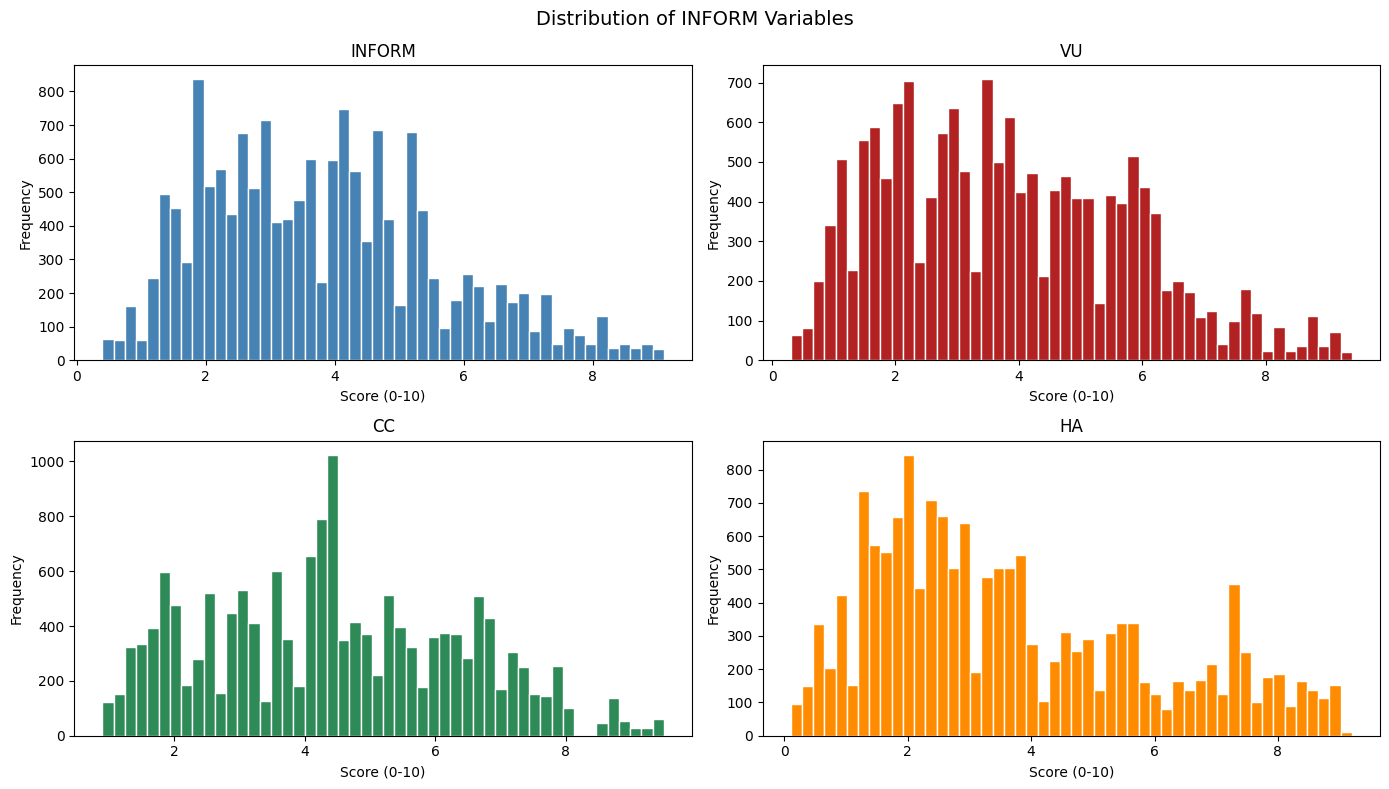

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of INFORM Variables', fontsize=14)

colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange']

for i, col in enumerate(inform_cols):
    ax = axes[i//2, i%2]
    ax.hist(df[col].dropna(), bins=50, color=colors[i], edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Score (0-10)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Unlike ACLED and IDMC, INFORM variables show no extreme skew , scores are distributed across the full 0-10 scale, reflecting structural differences between countries rather than event-driven spikes. `INFORM` and `CC` are concentrated in the mid-range (2-5), while `VU` is more uniformly distributed. `HA` shows a bimodal pattern, suggesting two distinct groups of countries, those with low hazard exposure and those with very high exposure.

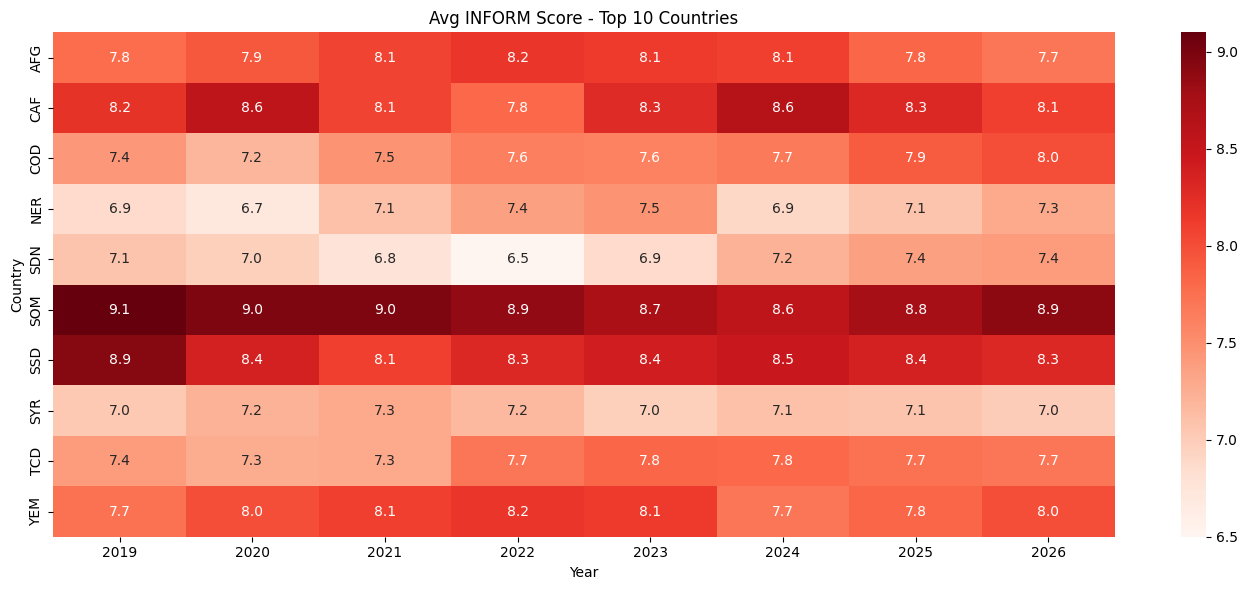

In [51]:
import seaborn as sns

df['year'] = pd.to_datetime(df['month']).dt.year

# Top 10 countries by average INFORM score
top10_inform = df.groupby('iso3')['INFORM'].mean().nlargest(10).index

yearly_inform = df[df['iso3'].isin(top10_inform)].groupby(['year', 'iso3'])['INFORM'].mean().round(2)

pivot_inform = yearly_inform.unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_inform, cmap='Reds', fmt='.1f', annot=True, ax=ax)
ax.set_title('Avg INFORM Score - Top 10 Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

#### Part 2: Bivariate Analysis
This section examines whether countries that are allocation-eligible show systematically higher INFORM scores. Since INFORM captures structural vulnerability rather than active conflict, the expectation is that eligible countries present higher risk scores across all four dimensions, confirming that chronic vulnerability is a precondition for humanitarian crises.

In [52]:
# Mean INFORM variables by allocation-eligible
df.groupby('allocation-eligible')[['INFORM', 'VU', 'CC', 'HA']].mean().round(2)

,INFORM,VU,CC,HA
allocation-eligible,,,,
0,3.68,3.69,4.35,3.53
1,7.03,7.13,6.88,7.28


Total onsets: 99


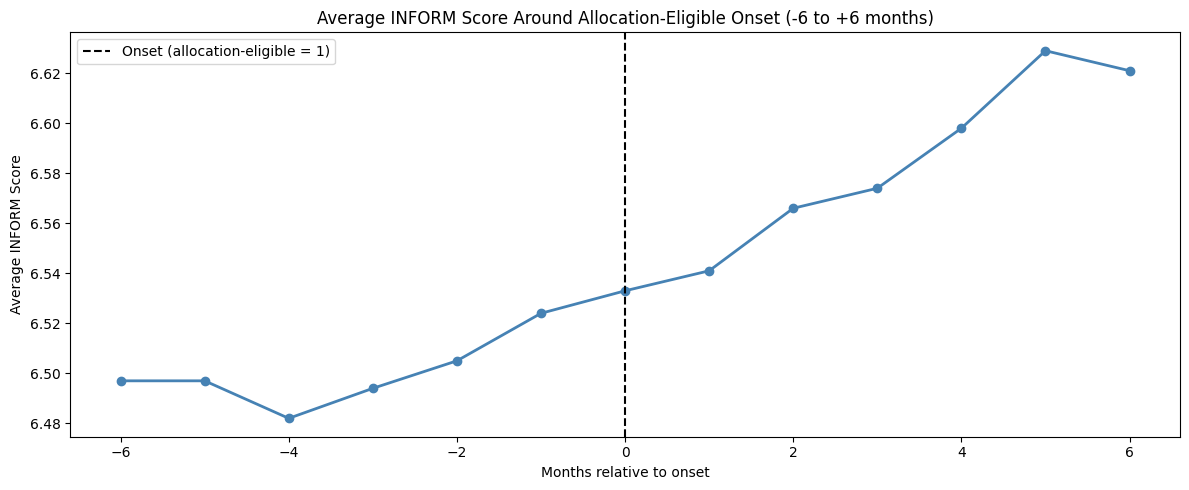

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df['month'] = pd.to_datetime(df['month'])
df = df.sort_values(['iso3', 'month'])

# Build onset
df['prev_eligible'] = df.groupby('iso3')['allocation-eligible'].shift(1)
onset = df[(df['allocation-eligible'] == 1) & (df['prev_eligible'] == 0)][['iso3', 'month']].copy()
print(f"Total onsets: {len(onset)}")

# Window around onset for INFORM
windows_inform = []
for _, row in onset.iterrows():
    country = row['iso3']
    onset_month = row['month']
    for t in range(-6, 7):
        target_month = onset_month + pd.DateOffset(months=t)
        match = df[(df['iso3'] == country) & (df['month'] == target_month)]
        if not match.empty:
            windows_inform.append({'months_to_onset': t,
                                   'INFORM': match['INFORM'].values[0]})

window_df_inform = pd.DataFrame(windows_inform)
avg_inform = window_df_inform.groupby('months_to_onset')['INFORM'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_inform.index, avg_inform.values, color='steelblue', linewidth=2, marker='o')
ax.axvline(x=0, color='black', linestyle='--', label='Onset (allocation-eligible = 1)')
ax.set_title('Average INFORM Score Around Allocation-Eligible Onset (-6 to +6 months)')
ax.set_xlabel('Months relative to onset')
ax.set_ylabel('Average INFORM Score')
ax.legend()
plt.tight_layout()
plt.show()

The INFORM score rises from 6.52 at t-6 to 6.56 at the onset, and continues increasing after the crisis begins, reaching 6.65 at t+4. This suggests that allocation-eligible countries are not only structurally more vulnerable before the crisis, but that their risk scores tend to worsen once the crisis is underway. Unlike EconAI and ACLED, the variation is small in magnitude , INFORM captures chronic structural risk that changes slowly over time, rather than acute conflict signals. This confirms its role as a background risk indicator rather than an early warning trigger.

### Severity Index

SOLO TIENE UNA COLUMNA: inform_severity_index